# Clustering en online retail

En el siguiente script implementaremos 2 hipotesis para realizar clustering y al final se realiza

## 1. Traer la base de datos y librerias 

In [371]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import   StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN
from IPython.display import Markdown



In [372]:
online_r=fetch_ucirepo(id=352)


In [373]:
df = online_r.data.original

# 4) ver primeras filas
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


## 2. EDA y Transformación

In [374]:
df.shape

(541909, 8)

In [375]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [376]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [377]:
# Detección de nulos dentro del df
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [378]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [379]:
# Se realiza la deteccion de duplicados
duplicados= df[df.duplicated()]
duplicados.shape[0]

5268

In [380]:
#Se eliminaron los duplicados
df=df.drop_duplicates(keep='first')
df.shape

(536641, 8)

Se eliminan las filas duplicadas que representan aproximadamente el 1% del df

In [381]:
df.shape[0]-541909

-5268

In [382]:
# se realiza transforamcion del logaritmo para poder graficar teniendo en cuenta valores negativos
df["Quantity_log"] = np.log1p(df["Quantity"])
df["UnitPrice_log"] = np.log1p(df["UnitPrice"])

c:\Users\Usuario\Documents\U_JAVERIANA\2_Semestre\MACHINE LEARNING\CLUSTERING\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Usuario\Documents\U_JAVERIANA\2_Semestre\MACHINE LEARNING\CLUSTERING\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


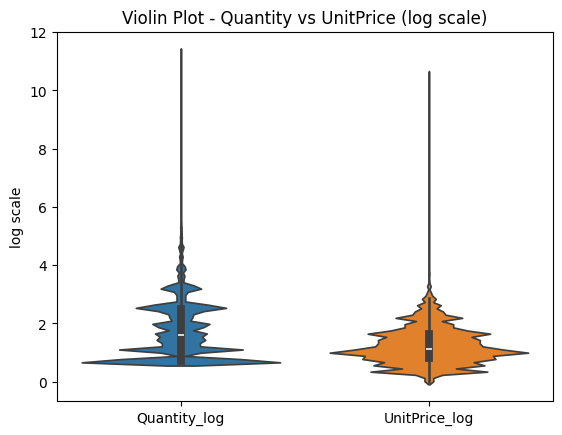

In [383]:
plt.figure()
sns.violinplot(data=df[["Quantity_log", "UnitPrice_log"]])
plt.title("Violin Plot - Quantity vs UnitPrice (log scale)")
plt.ylabel("log scale")
plt.show()

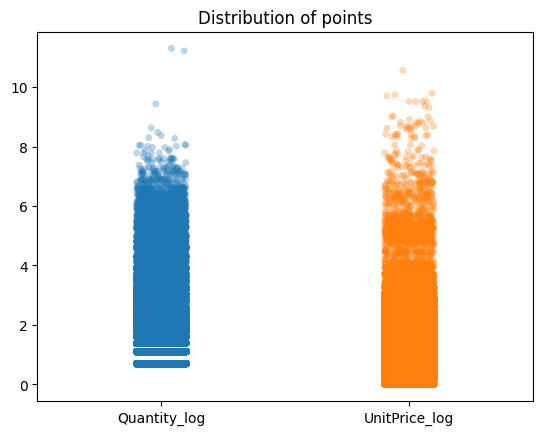

In [384]:
plt.figure()
sns.stripplot(data=df[["Quantity_log", "UnitPrice_log"]], alpha=0.3)
plt.title("Distribution of points")
plt.show()

In [385]:
# Se supone que todas las devoluciones autenticas comienzan por la letra C por 3 razones
# 1 la cantidad es negativa
# 2 el precio es positivo 
# 3 hay customer ID
Devoluciones=df.loc[df["InvoiceNo"].astype(str).str.startswith("C")]
Devoluciones

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom,-inf,3.349904
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom,-inf,1.731656
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,NaN,0.974560
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,NaN,0.254642
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,NaN,0.254642
...,...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom,NaN,0.604316
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom,-inf,5.419162
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom,NaN,2.480731
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom,-inf,0.810930


**NO SE ANALIZARAN LAS DEVOLUCIONES PUESTO QUE NO ES EL OBJETIVO DEL PROYECTO**

In [386]:
Devoluciones.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID        379
Country             0
Quantity_log     5167
UnitPrice_log       0
dtype: int64

In [387]:
# se supone que si tiene cantidad negativa y no comienza por la letra C es porque 
#son transacciones de la empresa o algo por el estilo
df_neg = df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]
df_neg

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
2406,536589,21777,NaN,-10,12/1/2010 16:50,0.0,NaN,United Kingdom,NaN,0.0
4347,536764,84952C,NaN,-38,12/2/2010 14:42,0.0,NaN,United Kingdom,NaN,0.0
7188,536996,22712,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom,NaN,0.0
7189,536997,22028,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom,NaN,0.0
7190,536998,85067,NaN,-6,12/3/2010 15:30,0.0,NaN,United Kingdom,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,12/7/2011 18:36,0.0,NaN,United Kingdom,NaN,0.0
535335,581212,22578,lost,-1050,12/7/2011 18:38,0.0,NaN,United Kingdom,NaN,0.0
535336,581213,22576,check,-30,12/7/2011 18:38,0.0,NaN,United Kingdom,NaN,0.0
536908,581226,23090,missing,-338,12/8/2011 9:56,0.0,NaN,United Kingdom,NaN,0.0


In [388]:
# Puede que haya transacciones por fuera de los valores anteriores que tengan candidades, se encontro q
#este tipo de transacciones son autenticas de la operacion de la empresa 
df_precio_1 = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] == 0)
]
df_precio_1

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom,4.043051,0.0
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom,0.693147,0.0
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom,0.693147,0.0
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom,0.693147,0.0
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom,0.693147,0.0
...,...,...,...,...,...,...,...,...,...,...
535334,581211,22142,check,14,12/7/2011 18:36,0.0,NaN,United Kingdom,2.708050,0.0
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom,3.332205,0.0
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom,5.484797,0.0
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom,5.707110,0.0


In [389]:
# La suma de 1174 + 1336 es igual a todos los valores con precio 0
df_precio_2 = df[
    (df["UnitPrice"] == 0)]
df_precio_2

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom,4.043051,0.0
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom,0.693147,0.0
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom,0.693147,0.0
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom,0.693147,0.0
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom,0.693147,0.0
...,...,...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom,3.332205,0.0
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom,5.484797,0.0
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom,5.707110,0.0
538554,581408,85175,NaN,20,12/8/2011 14:06,0.0,NaN,United Kingdom,3.044522,0.0


**Se decide BORRAR TODAS las columnas con UNIT PRICE = 0 por los motivos antes mencionados, tener en cuenta que esto es RUIDO generado por las operaciones de la empresa**

In [390]:
# Revision transacciones con una sola letra en la columna de Stock Code
Transaccioon_letra1 =df[
    (df["StockCode"].astype(str).str.len() == 1) &
    (df["StockCode"].astype(str).str.isalpha())
]
Transaccioon_letra1["StockCode"].value_counts()

StockCode
M    566
D     77
S     62
B      3
m      1
Name: count, dtype: int64

**Se decide BORRAR todas las filas de StockCode que tengan una sola letra letra ya que son operaciones de la empresa definidas M= Manual, D= discount , S= samples, B= bads, etc**

In [391]:
#cuantos paises hay. 
Paises=df["Country"].value_counts()
Paises

Country
United Kingdom          490300
Germany                   9480
France                    8541
EIRE                      8184
Spain                     2528
Netherlands               2371
Belgium                   2069
Switzerland               1994
Portugal                  1510
Australia                 1258
Norway                    1086
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Unspecified                442
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     294
USA                        291
Hong Kong                  284
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


Vale la pena hacer un analisis solamente para UK y para el resto del mundo por aparte para realizar segmentos y que el algoritmo no sesge

En este momento, objetivamente se tiene 4 modelos para construir ya que alrededor del 90% de los datos son de UK y por lo tanto el algoritmo estaria sesgado para interpretar los datos de uk, por lo tanto valdria la pena separar UK del resto del mundo, ahora si se hace esta division seguramente deberia hacerse tambien con respecto al modelo de devoluciones antes planteado.

### 2.1 TRANSFORMACION DE LECTURA

In [392]:
# Cambio de lectura del formato fecha
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%m/%d/%Y %H:%M"
)

### 2.2 DATA CLEANING

LIMPIEZA UNIT PRICE = 0 & STOCK CODE = SOLO UNA LETRA & SOCK CODE REVISION MANUAL = GITFT,PAD,POST, DOT, CRUK, BANK CHARGES, AMAZON FEE 

In [393]:
# Limpieza previa
df["StockCode"] = df["StockCode"].astype(str).str.strip().str.lower()

# Lista manual
invalid_codes = ["gift", "pad", "post", "dot", "cruk", "bank charges", "amazon fee"]

# Condiciones
cond_price = df["UnitPrice"] == 0
cond_negative_Quantity = df['Quantity'] < 0
cond_one_letter = (
    (df["StockCode"].str.len() == 1) &
    (df["StockCode"].str.isalpha())
)

cond_manual = df["StockCode"].isin(invalid_codes)

# Filtro final (mantener lo válido)
df_clean = df[~(cond_price | cond_one_letter | cond_manual | cond_negative_Quantity)]

In [394]:
# impresion de lectura de los datos removidos
df_removed = df[cond_price | cond_one_letter | cond_manual| cond_negative_Quantity]
df_removed

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Quantity_log,UnitPrice_log
45,536370,post,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France,1.386294,2.944439
141,C536379,d,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-inf,3.349904
154,C536383,35004c,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-inf,1.731656
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,NaN,0.974560
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,NaN,0.254642
...,...,...,...,...,...,...,...,...,...,...
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,-inf,0.810930
541717,C581569,20979,36 PENCILS TUBE RED RETROSPOT,-5,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,NaN,0.810930
541730,581570,post,POSTAGE,1,2011-12-09 11:59:00,18.00,12662.0,Germany,0.693147,2.944439
541767,581574,post,POSTAGE,2,2011-12-09 12:09:00,18.00,12526.0,Germany,1.098612,2.944439


In [395]:
df_clean.shape

(522714, 10)

In [396]:
# cantidad de filas original, filtrada y cantidad removida
len(df), len(df_clean), len(df_removed)

(536641, 522714, 13927)

### 2.3 Revisión si vale la pena analizar devoluciones y resto del mundo en cifras significativas del negocio

In [397]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

Se realiza filtro por UK Y resto del mundo para revisar el radio de valor entre transacciones.

In [398]:
# filtro de UK
UK_df= df_clean[df_clean['Country']=='United Kingdom']
# Dinero UK 
dinero_UK=df_clean.loc[df_clean['Country'] == 'United Kingdom','TotalPrice'].sum()
# Transacciones de UK
T_UK=df_clean.loc[df_clean['Country'] == 'United Kingdom','TotalPrice'].count()
#Radio de UK
rate_UK=dinero_UK / T_UK
rate_UK

np.float64(18.249510004447348)

In [399]:
#filtro $$ resto del mundo
dinero_resto_mundo=df_clean.loc[df_clean['Country'] != 'United Kingdom','TotalPrice'].sum()
# filtro Transacciones resto del mundoi
cantidad_t_resto_mundo=df_clean.loc[df_clean['Country'] != 'United Kingdom','TotalPrice'].count()
#Radio de dinero resto del mundo
rate_r = dinero_resto_mundo /cantidad_t_resto_mundo 
rate_r

np.float64(34.912206181328095)

In [400]:
# Porcentaje de dinero del resto del mundo
suma_total= dinero_UK+dinero_resto_mundo
porcentaje_rest= (dinero_resto_mundo / suma_total)*100
porcentaje_rest

np.float64(14.883569357395285)

In [401]:

null_revenue = UK_df[UK_df['CustomerID'].isnull()]['TotalPrice'].sum()

null_revenue / dinero_UK

np.float64(0.1711639218640266)

### 2.4 Crear Columnas 

In [402]:
UK_df["TotalPrice"] = UK_df["Quantity"] * UK_df["UnitPrice"]

Creacion de RFM: Recency(ultimos dias de compra), frequency(cuantas compras hizo) and monetary(cuanto gasto el cliente en total)

In [403]:
snapshot_date = UK_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = UK_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12747.0,2,11,4196.01
2,12748.0,1,206,31650.78
3,12749.0,4,5,4090.88
4,12820.0,3,4,942.34
...,...,...,...,...
3911,18280.0,278,1,180.60
3912,18281.0,181,1,80.82
3913,18282.0,8,2,178.05
3914,18283.0,4,16,2039.58


In [404]:
len(rfm[rfm['Monetary'] <= 0 ])
    

0

Como primera conclusion se aconseja para futuros analisis, realizar el analisis de **DEVOLUCIONES** 


In [413]:
Markdown(f"""
Aunque el resto del mundo representa aproximadamente el **{porcentaje_rest:.2f}%** del ingreso total y presenta un mayor valor promedio por transacción, su bajo volumen relativo frente al Reino Unido introduce un desbalance significativo en los datos. Dado que el objetivo es realizar segmentación de clientes mediante clustering, se prioriza el análisis sobre el mercado del Reino Unido para garantizar la estabilidad y representatividad de los clusters.
""")


Aunque el resto del mundo representa aproximadamente el **14.88%** del ingreso total y presenta un mayor valor promedio por transacción, su bajo volumen relativo frente al Reino Unido introduce un desbalance significativo en los datos. Dado que el objetivo es realizar segmentación de clientes mediante clustering, se prioriza el análisis sobre el mercado del Reino Unido para garantizar la estabilidad y representatividad de los clusters.


Se realizaran dos modelos de clustering como se muestra en la siguiente figura:




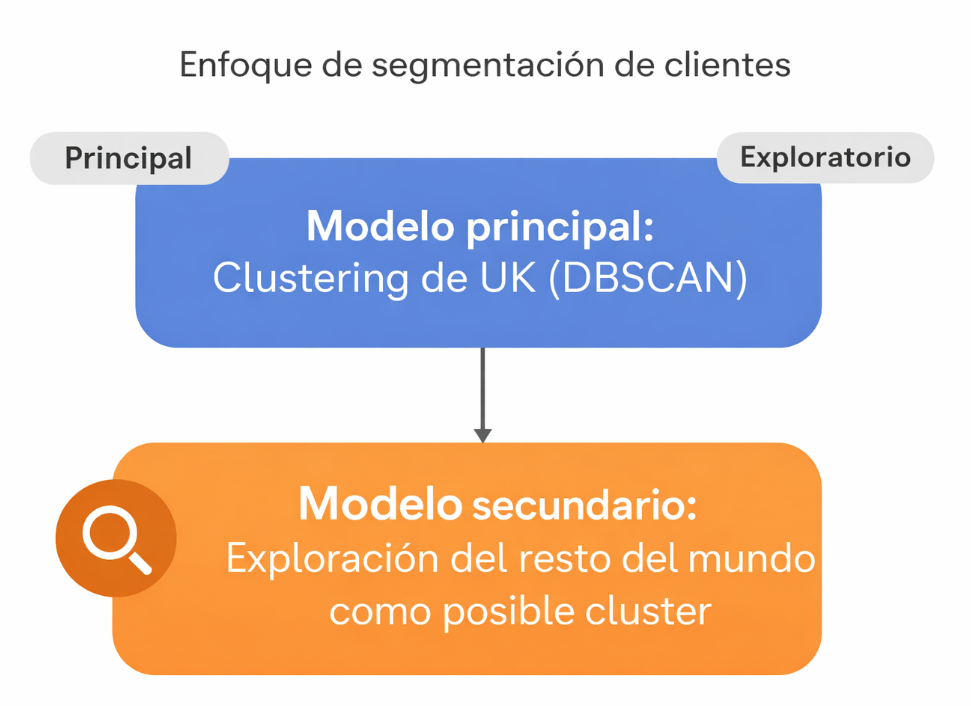

## 3 PROCESAMIENTO DE DATOS


### 3.1 PIPELINE DE TRANFORMACION NUMERICA

In [405]:
X = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X



,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,11,4196.01
2,1,206,31650.78
3,4,5,4090.88
4,3,4,942.34
...,...,...,...
3911,278,1,180.60
3912,181,1,80.82
3913,8,2,178.05
3914,4,16,2039.58


In [406]:
UK_df.isnull().sum()

InvoiceNo             0
StockCode             0
Description           0
Quantity              0
InvoiceDate           0
UnitPrice             0
CustomerID       130032
Country               0
Quantity_log          0
UnitPrice_log         0
TotalPrice            0
dtype: int64

In [407]:
ratio_null_customerid=(UK_df['CustomerID'].isnull().sum()/len(UK_df))*100
ratio_null_customerid

np.float64(27.150126217018105)

In [408]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dbscan', DBSCAN(eps=0.8,min_samples=5))
])

pipeline.fit(X)
labels = pipeline.named_steps['dbscan'].labels_

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('dbscan', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.8
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None


## 4 ESTIMACION DE CLUSTERS A GENERAR

## 5 CONSTRUCCION DEL MODELO (PIPELINES)

# 6 EVALUACION DE LOS RESULTADOS

# 7 ANALISIS DE LOS RESULTADOS

1. 